In [1]:
# Importing Important Libaries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importing Important Libaries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [3]:
# Import the Dataset
df = pd.read_csv('/content/train.csv')

In [4]:
# Datasets Uniqe Columns
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
# Shape of the Dataset
df.shape

(891, 12)

In [6]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
824,825,0,3,"Panula, Master. Urho Abraham",male,2.0,4,1,3101295,39.6875,NaN,S
473,474,1,2,"Jerwan, Mrs. Amin S (Marie Marthe Thuillard)",female,23.0,0,0,SC/AH Basle 541,13.7917,D,C
757,758,0,2,"Bailey, Mr. Percy Andrew",male,18.0,0,0,29108,11.5000,NaN,S
157,158,0,3,"Corn, Mr. Harry",male,30.0,0,0,SOTON/OQ 392090,8.0500,NaN,S
674,675,0,2,"Watson, Mr. Ennis Hastings",male,NaN,0,0,239856,0.0000,NaN,S


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


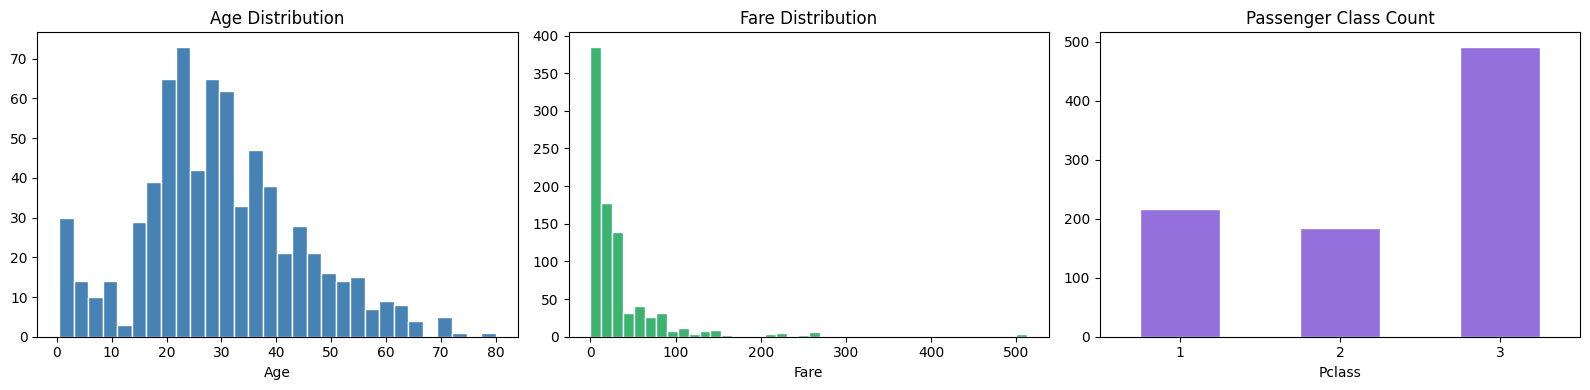

In [10]:
# Age Distribution

# ── Section 3: Univariate Analysis ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Age distribution
axes[0].hist(df['Age'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

# Fare distribution
axes[1].hist(df['Fare'], bins=40, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Fare Distribution')
axes[1].set_xlabel('Fare')

# Pclass count
df['Pclass'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='mediumpurple', edgecolor='white')
axes[2].set_title('Passenger Class Count')
axes[2].set_xlabel('Pclass')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_11836/4055217889.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=df, ax=axes[1][1], palette='Set2')


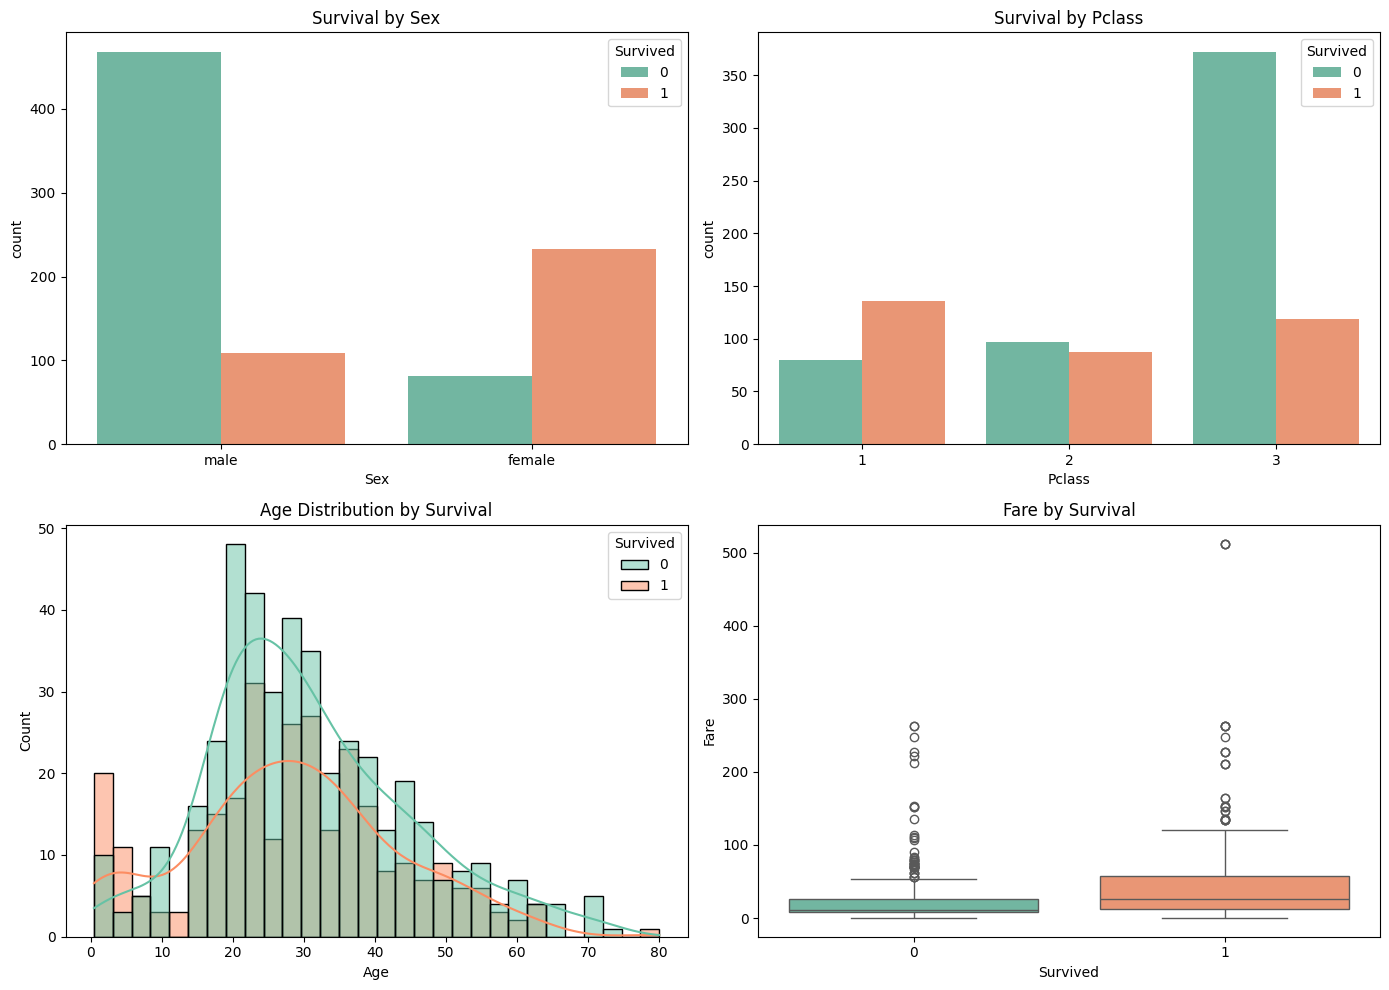

In [11]:
# ── Section 4: Bivariate Analysis ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Survival by Sex
sns.countplot(x='Sex', hue='Survived', data=df, ax=axes[0][0], palette='Set2')
axes[0][0].set_title('Survival by Sex')

# Survival by Pclass
sns.countplot(x='Pclass', hue='Survived', data=df, ax=axes[0][1], palette='Set2')
axes[0][1].set_title('Survival by Pclass')

# Age vs Survived
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, ax=axes[1][0], palette='Set2')
axes[1][0].set_title('Age Distribution by Survival')

# Fare vs Survived
sns.boxplot(x='Survived', y='Fare', data=df, ax=axes[1][1], palette='Set2')
axes[1][1].set_title('Fare by Survival')

plt.tight_layout()
plt.show()

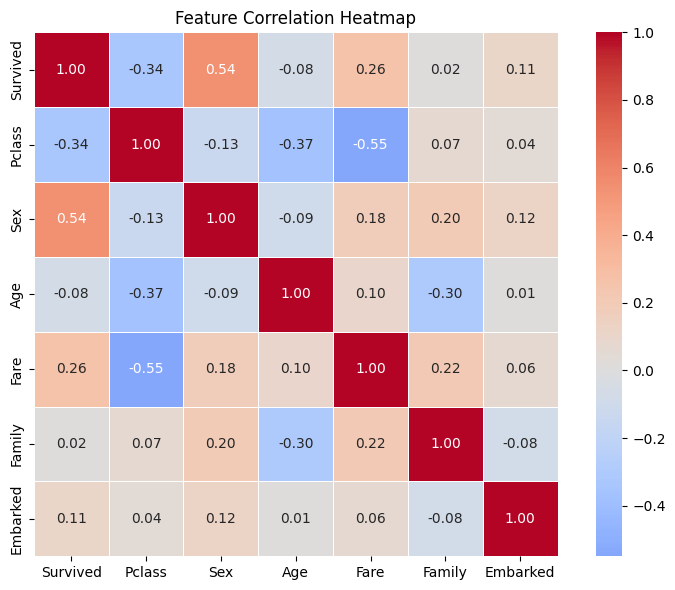

In [12]:
# ── Section 5: Correlation Heatmap ────────────────────────────
plt.figure(figsize=(8, 6))

# Encode categoricals temporarily for correlation
df_corr = df.copy()
df_corr['Sex'] = df_corr['Sex'].map({'male': 0, 'female': 1})
df_corr['Embarked'] = df_corr['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df_corr['Family'] = df_corr['SibSp'] + df_corr['Parch']

corr = df_corr[['Survived','Pclass','Sex','Age','Fare','Family','Embarked']].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [13]:
df = df.drop(['PassengerId','Name','Ticket','Cabin'],axis = 1)

In [14]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [15]:
df['Family'] = df['SibSp'] + df['Parch']

In [16]:
df = df.drop(['SibSp','Parch'],axis = 1)

In [17]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Family
0,0,3,male,22.0,7.2500,S,1
1,1,1,female,38.0,71.2833,C,1
2,1,3,female,26.0,7.9250,S,0
3,1,1,female,35.0,53.1000,S,1
4,0,3,male,35.0,8.0500,S,0


In [18]:
# Handling Missing Data in Age and Embarked Column

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [19]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0
Embarked,0
Family,0


In [20]:
# Applying StandardScaler
st = StandardScaler()
df['Age'] = st.fit_transform(df[['Age']])
df['Fare'] = st.fit_transform(df[['Fare']])
df['Family'] = st.fit_transform(df[['Family']])

In [21]:
# Applying LabelEncoder
le = LabelEncoder()
df['Pclass'] = le.fit_transform(df['Pclass'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [40]:
# Applying OneHotEncoder
ohe = OneHotEncoder()
sex_encoded = pd.get_dummies(df['Sex'], drop_first=True)
df['Sex'] = sex_encoded

In [41]:
x = df.drop('Survived',axis = 1)
y = df['Survived']

In [42]:
# Take train and test data

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [43]:
log = LogisticRegression()
log.fit(x_train,y_train)

LogisticRegression()

In [44]:
y_pred = log.predict(x_test)
print('Accuracy_score :-',accuracy_score(y_test,y_pred))
print('Confusion_matrix :-',confusion_matrix(y_test,y_pred))
print('Classification_report :-',classification_report(y_test,y_pred))

Accuracy_score :- 0.8044692737430168
Confusion_matrix :- [[90 15]
 [20 54]]
Classification_report :-               precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In [45]:
from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier(
    learning_rate='constant',
    eta0=0.01,
    max_iter=100,
    random_state=42
)

sgd.fit(x_train,y_train)

SGDClassifier(eta0=0.01, learning_rate='constant', max_iter=100,
              random_state=42)

In [46]:
y_pred = sgd.predict(x_test)
print('Accuracy_score :-',accuracy_score(y_test,y_pred))
print('Confusion_matrix :-',confusion_matrix(y_test,y_pred))
print('Classification_report :-',classification_report(y_test,y_pred))

Accuracy_score :- 0.7821229050279329
Confusion_matrix :- [[89 16]
 [23 51]]
Classification_report :-               precision    recall  f1-score   support

           0       0.79      0.85      0.82       105
           1       0.76      0.69      0.72        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [47]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [48]:
y_pred = rf.predict(x_test)
print('Accuracy_score :-',accuracy_score(y_test,y_pred))
print('Confusion_matrix :-',confusion_matrix(y_test,y_pred))
print('Classification_report :-',classification_report(y_test,y_pred))

Accuracy_score :- 0.8212290502793296
Confusion_matrix :- [[89 16]
 [16 58]]
Classification_report :-               precision    recall  f1-score   support

           0       0.85      0.85      0.85       105
           1       0.78      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179



In [49]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [50]:
y_pred = dt.predict(x_test)
print('Accuracy_score :-',accuracy_score(y_test,y_pred))
print('Confusion_matrix :-',confusion_matrix(y_test,y_pred))
print('Classification_report :-',classification_report(y_test,y_pred))

Accuracy_score :- 0.770949720670391
Confusion_matrix :- [[82 23]
 [18 56]]
Classification_report :-               precision    recall  f1-score   support

           0       0.82      0.78      0.80       105
           1       0.71      0.76      0.73        74

    accuracy                           0.77       179
   macro avg       0.76      0.77      0.77       179
weighted avg       0.77      0.77      0.77       179



In [51]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [52]:
y_pred = knn.predict(x_test)
print('Accuracy_score :-',accuracy_score(y_test,y_pred))
print('Confusion_matrix :-',confusion_matrix(y_test,y_pred))
print('Classification_report :-',classification_report(y_test,y_pred))

Accuracy_score :- 0.7932960893854749
Confusion_matrix :- [[87 18]
 [19 55]]
Classification_report :-               precision    recall  f1-score   support

           0       0.82      0.83      0.82       105
           1       0.75      0.74      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



In [53]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [54]:
y_pred = xgb.predict(x_test)
print('Accuracy_score :-',accuracy_score(y_test,y_pred))
print('Confusion_matrix :-',confusion_matrix(y_test,y_pred))
print('Classification_report :-',classification_report(y_test,y_pred))

Accuracy_score :- 0.8156424581005587
Confusion_matrix :- [[90 15]
 [18 56]]
Classification_report :-               precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179



In [55]:
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': log,
    'SGD Classifier':      sgd,
    'Random Forest':       rf,
    'Decision Tree':       dt,
    'KNN':                 knn,
    'XGBoost':             xgb
}

results = []
for name, model in models.items():
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': round(acc * 100, 2)})

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df.index += 1
print(results_df.to_string())

                 Model  Accuracy
1        Random Forest     82.12
2              XGBoost     81.56
3  Logistic Regression     80.45
4                  KNN     79.33
5       SGD Classifier     78.21
6        Decision Tree     77.09
